# Formatos de archivos de imagen

**Duración estimada:** 65 minutos

## Objetivo

En este cuaderno vas a comparar varios formatos habituales de imagen para entender qué conservan, qué sacrifican y por qué esa decisión importa cuando armás un pipeline de restauración.

## Resultados de aprendizaje

Al final vas a poder:

- distinguir formato de archivo, resolución y espacio de color;
- explicar la diferencia entre compresión con pérdida y sin pérdida;
- comparar tamaño y aspecto visual entre varios formatos;
- justificar qué formato conviene para original, copia de trabajo y entrega final.


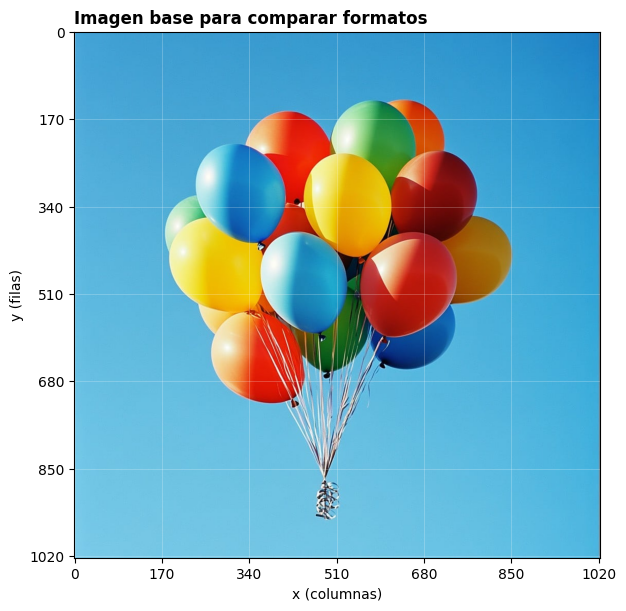

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


CARPETA_IMAGENES = Path("Imagenes")


def abrir_imagen_bgr(nombre_archivo):
    """Abre una imagen en color usando el orden BGR de OpenCV."""
    ruta = CARPETA_IMAGENES / nombre_archivo
    imagen_bgr = cv2.imread(str(ruta), cv2.IMREAD_COLOR)
    if imagen_bgr is None:
        raise FileNotFoundError(f"No pude abrir la imagen: {ruta}")
    return imagen_bgr


def abrir_imagen_rgb(nombre_archivo):
    """Abre una imagen y la convierte a RGB para mostrarla con Matplotlib."""
    imagen_bgr = abrir_imagen_bgr(nombre_archivo)
    imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)
    return imagen_rgb


def preparar_eje_imagen(eje, imagen, titulo, mapa=None):
    """Muestra una imagen conservando ejes y coordenadas visibles."""
    eje.imshow(imagen, cmap=mapa)
    eje.set_title(titulo, loc="left", fontweight="bold")
    eje.set_xlabel("x (columnas)")
    eje.set_ylabel("y (filas)")

    if imagen.ndim == 2:
        alto, ancho = imagen.shape
    else:
        alto, ancho = imagen.shape[:2]

    paso_x = max(50, ancho // 6)
    paso_y = max(50, alto // 6)
    eje.set_xticks(np.arange(0, ancho + 1, paso_x))
    eje.set_yticks(np.arange(0, alto + 1, paso_y))
    eje.grid(color="white", alpha=0.25, linewidth=0.6)


def mostrar_una_imagen(imagen, titulo, mapa=None, tamano=(8, 6)):
    fig, eje = plt.subplots(figsize=tamano, constrained_layout=True)
    preparar_eje_imagen(eje, imagen, titulo, mapa)
    plt.show()


def mostrar_varias_imagenes(imagenes, titulos, mapas=None, tamano=(15, 5)):
    if mapas is None:
        mapas = [None] * len(imagenes)

    fig, ejes = plt.subplots(1, len(imagenes), figsize=tamano, constrained_layout=True)
    if len(imagenes) == 1:
        ejes = [ejes]

    for eje, imagen, titulo, mapa in zip(ejes, imagenes, titulos, mapas):
        preparar_eje_imagen(eje, imagen, titulo, mapa)

    plt.show()


def mostrar_histograma_gris(imagen_gris, titulo):
    histograma, bordes = np.histogram(imagen_gris.ravel(), bins=256, range=(0, 256))
    plt.figure(figsize=(9, 4))
    plt.plot(bordes[:-1], histograma, color="black")
    plt.title(titulo, loc="left", fontweight="bold")
    plt.xlabel("Intensidad")
    plt.ylabel("Cantidad de píxeles")
    plt.grid(alpha=0.3)
    plt.xlim(0, 255)
    plt.show()


def mostrar_histogramas_bgr(imagen_bgr, titulo_general):
    nombres = ["azul", "verde", "rojo"]
    colores = ["tab:blue", "tab:green", "tab:red"]
    fig, ejes = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

    for indice in range(3):
        histograma = cv2.calcHist([imagen_bgr], [indice], None, [256], [0, 256]).ravel()
        ejes[indice].plot(histograma, color=colores[indice])
        ejes[indice].set_title(f"Canal {nombres[indice]}", loc="left", fontweight="bold")
        ejes[indice].set_xlabel("Intensidad")
        ejes[indice].set_ylabel("Frecuencia")
        ejes[indice].grid(alpha=0.25)

    fig.suptitle(titulo_general, x=0.01, ha="left", fontweight="bold")
    plt.show()

import tempfile


imagen_bgr = abrir_imagen_bgr("globos.jpg")
imagen_rgb = cv2.cvtColor(imagen_bgr, cv2.COLOR_BGR2RGB)

mostrar_una_imagen(imagen_rgb, "Imagen base para comparar formatos")


## 1. Formato no es lo mismo que tamaño ni que color

Cuando hablamos de formato de imagen no estamos hablando de cuántos píxeles tiene una foto ni de si la vemos en RGB o en grises. El formato define **cómo se guarda** esa información.

Algunas preguntas importantes son estas:

- ¿usa compresión con pérdida o sin pérdida?
- ¿admite transparencia?
- ¿qué tan grande queda el archivo?
- ¿cuán útil resulta para archivo, edición o entrega?


In [2]:
formatos = [
    ("jpeg_calidad_alta.jpg", [cv2.IMWRITE_JPEG_QUALITY, 95]),
    ("jpeg_calidad_baja.jpg", [cv2.IMWRITE_JPEG_QUALITY, 40]),
    ("png.png", [cv2.IMWRITE_PNG_COMPRESSION, 3]),
    ("tiff.tiff", []),
    ("bmp.bmp", []),
    ("webp.webp", [cv2.IMWRITE_WEBP_QUALITY, 80]),
]

resultados = []

with tempfile.TemporaryDirectory() as carpeta_temporal:
    carpeta_temporal = Path(carpeta_temporal)

    for nombre_archivo, parametros in formatos:
        ruta_archivo = carpeta_temporal / nombre_archivo
        se_pudo_guardar = cv2.imwrite(str(ruta_archivo), imagen_bgr, parametros)

        if se_pudo_guardar:
            tamano_kb = ruta_archivo.stat().st_size / 1024
            resultados.append((nombre_archivo, round(tamano_kb, 1), ruta_archivo.suffix))
        else:
            resultados.append((nombre_archivo, "no disponible", "-"))

print("Archivo".ljust(25), "Tamaño aproximado".ljust(20), "Extensión")
print("-" * 60)
for nombre_archivo, tamano, extension in resultados:
    print(nombre_archivo.ljust(25), str(tamano).ljust(20), extension)


Archivo                   Tamaño aproximado    Extensión
------------------------------------------------------------
jpeg_calidad_alta.jpg     114.1                .jpg
jpeg_calidad_baja.jpg     38.1                 .jpg
png.png                   651.4                .png
tiff.tiff                 919.8                .tiff
bmp.bmp                   3072.1               .bmp
webp.webp                 33.6                 .webp


**Lectura rápida de la tabla**

- `JPEG` suele dar archivos livianos, pero lo hace descartando información.
- `PNG` y `TIFF` conservan mejor la imagen, aunque pesan más.
- `BMP` ayuda a entender almacenamiento simple, pero rara vez es la mejor decisión práctica.
- `WebP` puede ser interesante si el flujo de trabajo lo soporta bien.


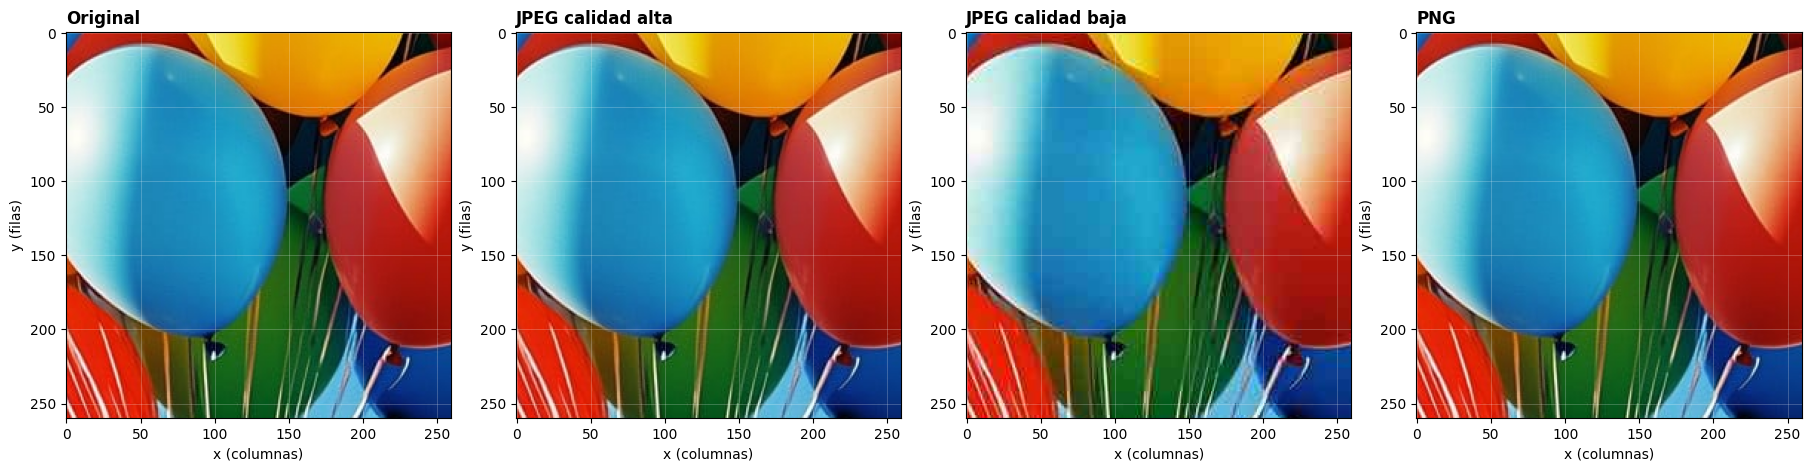

In [3]:
def recorte_central(imagen, alto=260, ancho=260):
    inicio_y = imagen.shape[0] // 2 - alto // 2
    inicio_x = imagen.shape[1] // 2 - ancho // 2
    fin_y = inicio_y + alto
    fin_x = inicio_x + ancho
    return imagen[inicio_y:fin_y, inicio_x:fin_x]


with tempfile.TemporaryDirectory() as carpeta_temporal:
    carpeta_temporal = Path(carpeta_temporal)

    ruta_jpeg_alta = carpeta_temporal / "alta.jpg"
    ruta_jpeg_baja = carpeta_temporal / "baja.jpg"
    ruta_png = carpeta_temporal / "sin_perdida.png"

    cv2.imwrite(str(ruta_jpeg_alta), imagen_bgr, [cv2.IMWRITE_JPEG_QUALITY, 95])
    cv2.imwrite(str(ruta_jpeg_baja), imagen_bgr, [cv2.IMWRITE_JPEG_QUALITY, 30])
    cv2.imwrite(str(ruta_png), imagen_bgr)

    jpeg_alta_rgb = cv2.cvtColor(cv2.imread(str(ruta_jpeg_alta)), cv2.COLOR_BGR2RGB)
    jpeg_baja_rgb = cv2.cvtColor(cv2.imread(str(ruta_jpeg_baja)), cv2.COLOR_BGR2RGB)
    png_rgb = cv2.cvtColor(cv2.imread(str(ruta_png)), cv2.COLOR_BGR2RGB)

    mostrar_varias_imagenes(
        [
            recorte_central(imagen_rgb),
            recorte_central(jpeg_alta_rgb),
            recorte_central(jpeg_baja_rgb),
            recorte_central(png_rgb),
        ],
        [
            "Original",
            "JPEG calidad alta",
            "JPEG calidad baja",
            "PNG",
        ],
        tamano=(18, 5),
    )


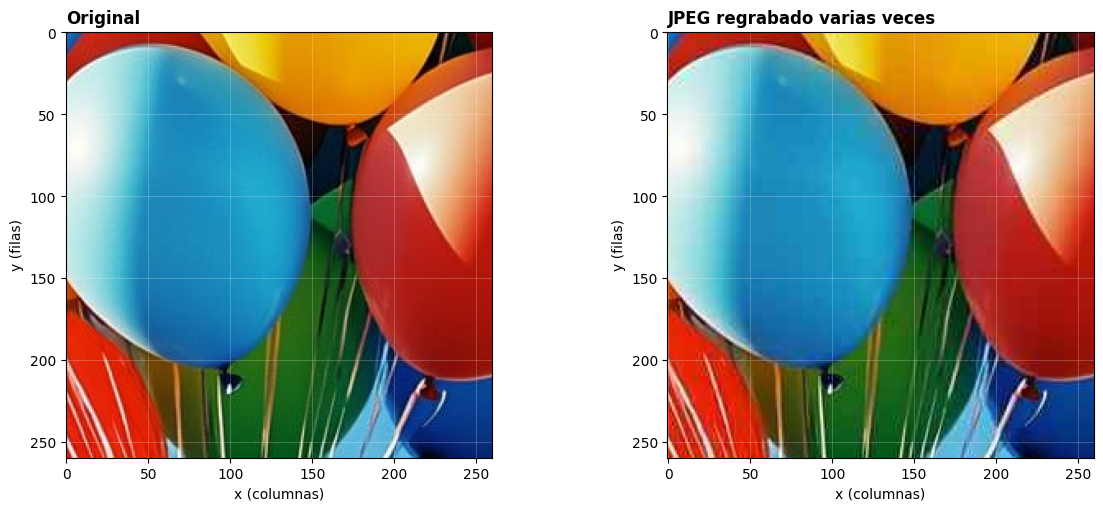

In [4]:
with tempfile.TemporaryDirectory() as carpeta_temporal:
    carpeta_temporal = Path(carpeta_temporal)
    imagen_actual = imagen_bgr.copy()

    for numero_guardado in range(8):
        ruta_archivo = carpeta_temporal / f"regrabada_{numero_guardado}.jpg"
        cv2.imwrite(str(ruta_archivo), imagen_actual, [cv2.IMWRITE_JPEG_QUALITY, 35])
        imagen_actual = cv2.imread(str(ruta_archivo), cv2.IMREAD_COLOR)

    imagen_regrabada_rgb = cv2.cvtColor(imagen_actual, cv2.COLOR_BGR2RGB)

mostrar_varias_imagenes(
    [recorte_central(imagen_rgb), recorte_central(imagen_regrabada_rgb)],
    ["Original", "JPEG regrabado varias veces"],
    tamano=(12, 5),
)


## Cierre

En un pipeline de restauración, el formato no es un detalle administrativo. Afecta cuánto conservás del original y cuánto degradás cada vez que volvés a guardar.

**Actividad breve**

Escribí qué formato elegirías para:

1. conservar el original;
2. trabajar durante la restauración;
3. exportar una versión final liviana para compartir.
